# Project1 --- Lineal Regression Manual Implementation

- Pedro Mauri Mtz - A01029143

## Imports

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os

ROOT = os.path.abspath(os.path.join(os.getcwd(), "../"))

## Load Data

In [5]:
x = []
y = []

with open(os.path.join(ROOT, "Datasets/ex1data1.txt"), "r") as file:
    next(file)
    for line in file:
        col1, col2 = line.split()        
        x.append(float(col1))
        y.append(float(col2))

## Initial Values

In [6]:
"""
Theta, inicializando ambas en 0
Alpha, razón de aprendizaje, 0,01
Numero de iteraciones, 1500
"""
theta = [0.0, 0.0]
alpha = 0.01
iteraciones = 1500

## Functions

In [7]:
def graficaDatos(x, y, theta):
    # Puntos:
    plt.scatter(x, y, color='blue', marker='o')
    # Recta:
    x_min = min(x)
    x_max = max(x)
    y_min = theta[0] + theta[1] * x_min
    y_max = theta[0] + theta[1] * x_max
    plt.plot([x_min, x_max], [y_min, y_max], color='red')
    # Configuración:
    plt.title('Ejercicio 1 - Regresión lineal')
    plt.legend(['Datos', 'Regresión'])
    plt.xlabel('Eje x')
    plt.ylabel('Eje y')
    plt.grid(True)
    # Graficar
    plt.show()

## Linear Regression Implementation

In [8]:
"""
Función encargada de ajustar los valores de theta, con el objetivo de disminuir el costo
y de esa forma obtener la recta optima segun los datos obtenidos.

h = theta0 + theta1 * x
e = (h - y)

Calculo de ajuste de las thetas:
theta0 = theta0 - alpha (1/m) * SumaT(e)
theta1 = theta1 - alpha (1/m) * SumaT(e * x)
"""
def gradianteDescendente(x, y, theta, alpha, iteraciones):
    m = len(y)
    theta = theta.copy()   # evita modificar la lista original
    historial_costo = []

    for i in range(iteraciones):
        temp0 = 0.0
        temp1 = 0.0
        for j in range(m):
            h = theta[0] + theta[1] * x[j]
            e = (h - y[j])
            temp0 += e
            temp1 += e * x[j]

        theta[0] -= alpha * 1/m * temp0
        theta[1] -= alpha * 1/m * temp1

        historial_costo.append(calculaCosto(x, y, theta))

        if (i + 1) % 100 == 0 or i == 0:
            print(f"Iteración: {i+1}, Theta: {theta}, Costo: {historial_costo[-1]}")

    print(f"Valores finales de theta: {theta}")

    return theta, historial_costo

In [9]:
"""
Función que calcula el costo de todos los datos, lo cual nos indica que exactitud de nuestros valores de theta0 y theta1

h = theta0 + theta1 * x
e = (h - y)

Costo total de todos los datos:
j = 1/2m * (sumaT(e^2))
"""
def calculaCosto(x, y, theta):
    m = len(y)
    sum_err = 0

    for i in range(m):
        h = theta[0] + theta[1] * x[i]
        e = (h - y[i])
        sum_err += e ** 2
    
    j = sum_err / (2 * m)
    
    return j

## Running Linear Regression

In [10]:
"""
La gradianteDescendente para ajustar los valores de theta para nuestra recta.
La calculaCosto para obtener el costo de la suma de los errores de todos los datos.
"""
theta, historial_costo = gradianteDescendente(x, y, theta, alpha, iteraciones)

Iteración: 1, Theta: [0.0583913505154639, 0.6532884974555674], Costo: 6.737190464870008
Iteración: 100, Theta: [-0.5765562303322348, 0.8595815252727688], Costo: 5.479975580535111
Iteración: 200, Theta: [-1.1245018112987775, 0.9146286023471152], Costo: 5.176152962891968
Iteración: 300, Theta: [-1.581991219049229, 0.9605883756602133], Costo: 4.964362046184745
Iteración: 400, Theta: [-1.9639571760237742, 0.9989609991537096], Costo: 4.816725268028978
Iteración: 500, Theta: [-2.2828672749589267, 1.0309989777517024], Costo: 4.713809531116865
Iteración: 600, Theta: [-2.549130928422701, 1.057748049855657], Costo: 4.6420682682928565
Iteración: 700, Theta: [-2.7714391381426187, 1.0800813208588218], Costo: 4.592058338363686
Iteración: 800, Theta: [-2.957048174396602, 1.09872776181806], Costo: 4.557197046645755
Iteración: 900, Theta: [-3.1120164249283144, 1.114296003496455], Costo: 4.53289567965796
Iteración: 1000, Theta: [-3.241402144274422, 1.1272942024281842], Costo: 4.515955503078912
Iteración

## Results

In [11]:
# Predicciones (x y y están en unidades de 10,000)
test = np.array([[1, 3.5], [1, 7]])
predicciones = test.dot(theta)

print(f"Ganancia para población de 35,000: ${predicciones[0] * 10000:,.2f}")
print(f"Ganancia para población de 70,000: ${predicciones[1] * 10000:,.2f}")

Ganancia para población de 35,000: $4,519.77
Ganancia para población de 70,000: $45,342.45


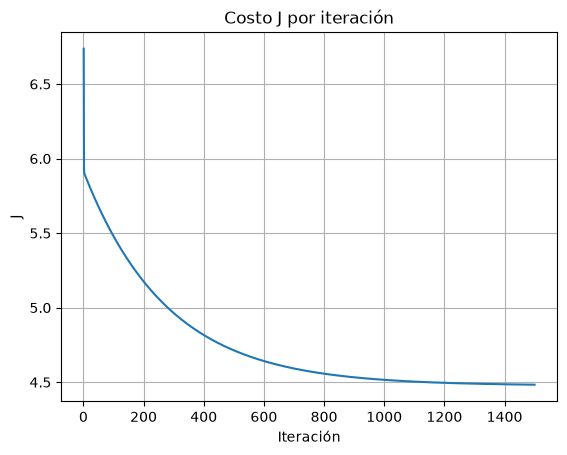

In [12]:
plt.plot(range(1, len(historial_costo) + 1), historial_costo)
plt.title('Costo J por iteración')
plt.xlabel('Iteración')
plt.ylabel('J')
plt.grid(True)
plt.show()

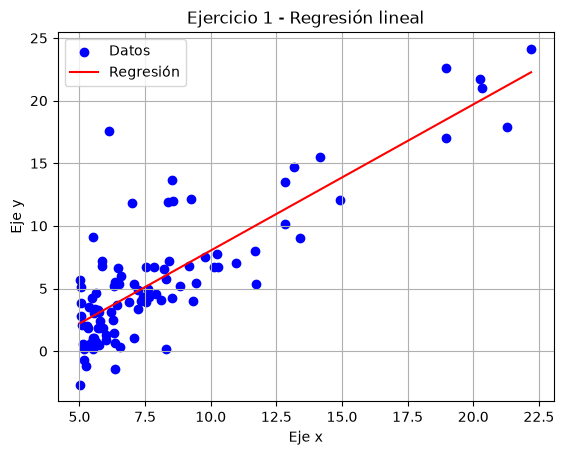

In [13]:
"""
La graficaDatos para visualizar los datos y la recta generada por las thetas ajustadas.
"""
graficaDatos(x, y, theta)